<a href="https://colab.research.google.com/github/Ajinkya63/AIOPS/blob/main/PCA_on_Iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PRINCIPAL COMPONENT ANALYSIS (PCA) ON IRIS DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# ============================================================
# LOAD IRIS DATA
# ============================================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(X.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# ============================================================
# STANDARDIZE VARIABLES
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [ ]:
# ============================================================
# PCA
# ============================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [ ]:
# ============================================================
# EIGEN VALUES
# ============================================================

eigenvalues = pca.explained_variance_

print("\nEigen Values")
print(np.round(eigenvalues,4))

# ============================================================


Eigen Values
[2.9381 0.9202 0.1477 0.0209]


In [ ]:
# VARIANCE EXPLAINED
# ============================================================

variance_ratio = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "Component": range(1,len(eigenvalues)+1),
    "EigenValue": eigenvalues,
    "Variance Explained (%)": variance_ratio*100,
    "Cumulative Variance (%)": np.cumsum(variance_ratio)*100
})

print("\nPCA Summary")
print(pca_summary)


PCA Summary
   Component  EigenValue  Variance Explained (%)  Cumulative Variance (%)
0          1    2.938085               72.962445                72.962445
1          2    0.920165               22.850762                95.813207
2          3    0.147742                3.668922                99.482129
3          4    0.020854                0.517871               100.000000


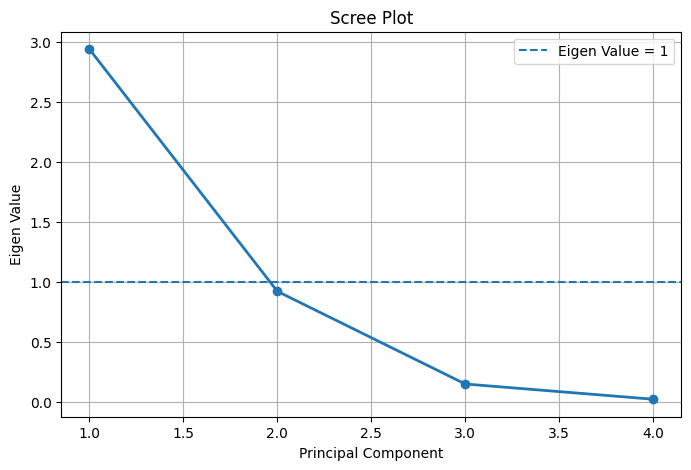

In [ ]:
# ============================================================
# SCREE PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(eigenvalues)+1),
    eigenvalues,
    marker='o',
    linewidth=2
)

plt.axhline(
    y=1,
    linestyle='--',
    label='Eigen Value = 1'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigen Value")
plt.title("Scree Plot")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# ============================================================
# PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)

print("\nPCA Loadings")
print(loadings)



PCA Loadings
                        PC1       PC2       PC3       PC4
sepal length (cm)  0.521066  0.377418  0.719566 -0.261286
sepal width (cm)  -0.269347  0.923296 -0.244382  0.123510
petal length (cm)  0.580413  0.024492 -0.142126  0.801449
petal width (cm)   0.564857  0.066942 -0.634273 -0.523597


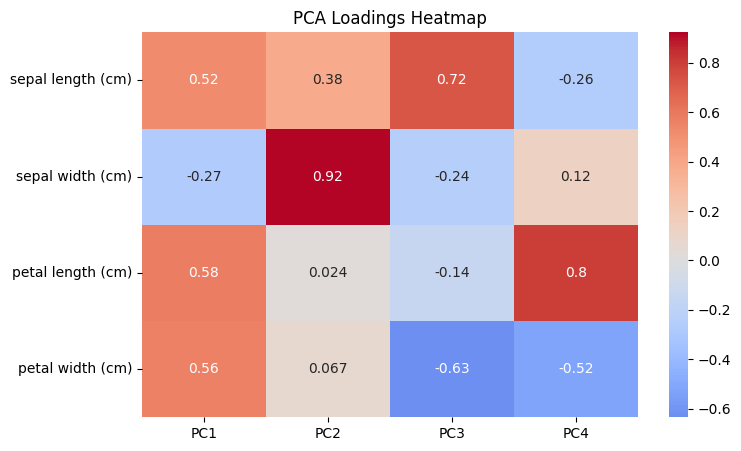

In [ ]:
# ============================================================
# HEATMAP OF PCA LOADINGS
# ============================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings Heatmap")

plt.show()


# **KMeans Cluster analysis**

In [ ]:
# ============================================================
# K-MEANS CLUSTERING WITH STANDARDIZATION
# SILHOUETTE INDEX + GROUP MEMBERSHIP
# IRIS DATASET
# ============================================================

import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# LOAD DATA
# ============================================================

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())

# ============================================================
# STANDARDIZE VARIABLES
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("\nMean After Standardization")
print(np.round(X_scaled.mean(axis=0),4))

print("\nStd Dev After Standardization")
print(np.round(X_scaled.std(axis=0),4))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Mean After Standardization
[-0. -0. -0. -0.]

Std Dev After Standardization
[1. 1. 1. 1.]


In [ ]:
# ============================================================
# SILHOUETTE ANALYSIS
# FIND OPTIMAL NUMBER OF CLUSTERS
# ============================================================

print("\nSilhouette Scores")

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}  Silhouette={score:.4f}")


Silhouette Scores
K=2  Silhouette=0.5818
K=3  Silhouette=0.4599
K=4  Silhouette=0.3839
K=5  Silhouette=0.3424
K=6  Silhouette=0.3259
K=7  Silhouette=0.3290
K=8  Silhouette=0.3346
K=9  Silhouette=0.3530
K=10  Silhouette=0.3500


In [ ]:
# FINAL MODEL (K=3)
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=20
)

cluster_membership = kmeans.fit_predict(X_scaled)
cluster_membership

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [ ]:
# ============================================================
# ADD GROUP MEMBERSHIP
# ============================================================

df["Cluster"] = cluster_membership

print("\nCluster Membership")
print(df.head())

# ============================================================
# NUMBER OF OBSERVATIONS IN EACH CLUSTER
# ============================================================

print("\nCluster Counts")

print(
    df["Cluster"].value_counts()
)



Cluster Membership
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  

Cluster Counts
Cluster
2    53
1    50
0    47
Name: count, dtype: int64


In [ ]:
# ============================================================
# CLUSTER CENTROIDS
# ============================================================

centroids = pd.DataFrame(
    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=df.columns[:-1]
)

print("\nCluster Centroids")

print(centroids)

# ============================================================
# CLUSTER PROFILE
# ============================================================

cluster_profile = df.groupby(
    "Cluster"
).mean()

print("\nCluster Profile")

print(cluster_profile)



Cluster Centroids
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           6.780851          3.095745           5.510638          1.972340
1           5.006000          3.428000           1.462000          0.246000
2           5.801887          2.673585           4.369811          1.413208

Cluster Profile
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 6.780851          3.095745           5.510638   
1                 5.006000          3.428000           1.462000   
2                 5.801887          2.673585           4.369811   

         petal width (cm)  
Cluster                    
0                1.972340  
1                0.246000  
2                1.413208  
